# **Customer Churn Prediction using Artificial Neural Networks (ANN)**

### **Project Objective**

The objective of this project is to develop a **Customer Churn Prediction System** using an **Artificial Neural Network (ANN)** to identify customers who are likely to discontinue a service or subscription.

Customer churn is a critical problem for businesses, especially in industries such as telecom, banking, and SaaS, where acquiring new customers is significantly more expensive than retaining existing ones. This project aims to leverage machine learning to enable **proactive retention strategies**.

The system is designed to:

- Predict the **probability of customer churn**  
- Identify key factors influencing churn behavior  
- Support **data-driven decision-making for customer retention**  
- Demonstrate the use of deep learning models for structured business data  

This project is highly applicable in:
- telecom customer retention  
- banking and financial services  
- subscription-based platforms  
- CRM and marketing analytics systems  


### **Dataset Used**

This project utilizes structured customer data containing demographic, account, and usage-related features.

### **Dataset Sources**

- **Telco Customer Churn Dataset (IBM / Kaggle)**

### **Dataset Characteristics**

The dataset includes:

- Customer demographic features:
  - gender  
  - age group (if available)  
  - location  

- Account-related information:
  - tenure  
  - contract type  
  - billing method  
  - monthly and total charges  

- Service usage features:
  - internet services  
  - add-on services (e.g., streaming, security)  

- Target variable:
  - **Churn (Yes/No)**  

### **How Dataset is Used in the Project**

The dataset is processed through a structured pipeline:

- **Data preprocessing**
  - handling missing values  
  - encoding categorical variables  
  - feature scaling for numerical attributes  

- **Feature engineering**
  - transformation of categorical features into numerical format  
  - normalization for ANN compatibility  

- **Train-validation-test split**
  - ensuring proper model evaluation  
  - avoiding data leakage  

- **Model training**
  - ANN trained on processed dataset  
  - learns non-linear relationships between features  

The dataset enables the model to capture **complex patterns in customer behavior**, which are critical for accurate churn prediction.

### **Import libraries and suppress unnecessary warnings:**

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore")

import glob
import pickle
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from scikeras.wrappers import KerasClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

print("Libraries imported successfully.")

Libraries imported successfully.


### **Load the dataset:**

In [2]:
data = pd.read_csv("Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### **Inspect dataset structure:**

In [3]:
print("Shape of dataset:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum())

print("\nData types:")
print(data.dtypes)

Shape of dataset: (10000, 14)

Column names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Data types:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


### **Drop irrelevant columns:**

In [4]:
# RowNumber, CustomerId, and Surname are identifiers and do not contribute to prediction.
data = data.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### **Encode binary categorical variable (Gender):**

In [5]:
label_encoder_gender = LabelEncoder()
data["Gender"] = label_encoder_gender.fit_transform(data["Gender"])

data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


### **One-hot encode Geography:**

In [6]:
try:
    onehot_encoder_geo = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder_geo = OneHotEncoder(handle_unknown="ignore", sparse=False)

geo_encoded = onehot_encoder_geo.fit_transform(data[["Geography"]])

geo_encoded_df = pd.DataFrame(
    geo_encoded,
    columns=onehot_encoder_geo.get_feature_names_out(["Geography"])
)

geo_encoded_df.head()

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


### **Combine encoded geography columns with original dataset:**

In [7]:
data = pd.concat([data.drop("Geography", axis=1), geo_encoded_df], axis=1)

data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


### **Save preprocessing objects:**

In [8]:
with open("label_encoder_gender.pkl", "wb") as file:
    pickle.dump(label_encoder_gender, file)

with open("onehot_encoder_geo.pkl", "wb") as file:
    pickle.dump(onehot_encoder_geo, file)

print("Encoders saved successfully.")

Encoders saved successfully.


### **Split dataset into features and target:**

In [9]:
X = data.drop("Exited", axis=1)
y = data["Exited"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (10000, 12)
Target shape: (10000,)


### **Train-test split:**

In [10]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train_df.shape)
print("X_test shape:", X_test_df.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 12)
X_test shape: (2000, 12)
y_train shape: (8000,)
y_test shape: (2000,)


### **Feature scaling:**

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully.")
print("Scaled training data shape:", X_train.shape)
print("Scaled testing data shape:", X_test.shape)

Scaler saved successfully.
Scaled training data shape: (8000, 12)
Scaled testing data shape: (2000, 12)


### **Define model-building function for GridSearchCV:**

In [12]:
def create_classification_model(hidden_units_1=64, hidden_units_2=32, learning_rate=0.001):
    model = Sequential([
        Dense(hidden_units_1, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(hidden_units_2, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

### **Hyperparameter tuning with GridSearchCV:**

In [13]:
keras_clf = KerasClassifier(
    model=create_classification_model,
    verbose=0
)

param_grid = {
    "model__hidden_units_1": [32, 64],
    "model__hidden_units_2": [16, 32],
    "model__learning_rate": [0.001, 0.01],
    "batch_size": [32, 64],
    "epochs": [30, 50]
}

grid = GridSearchCV(
    estimator=keras_clf,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=1
)

grid_result = grid.fit(X_train, y_train)

print("Best Cross-Validation Accuracy:", round(grid_result.best_score_, 4))
print("Best Parameters:", grid_result.best_params_)

Best Cross-Validation Accuracy: 0.8575
Best Parameters: {'batch_size': 64, 'epochs': 30, 'model__hidden_units_1': 64, 'model__hidden_units_2': 16, 'model__learning_rate': 0.001}


### **Extract best hyperparameters:**

In [14]:
best_params = grid_result.best_params_

best_hidden_units_1 = best_params["model__hidden_units_1"]
best_hidden_units_2 = best_params["model__hidden_units_2"]
best_learning_rate = best_params["model__learning_rate"]
best_batch_size = best_params["batch_size"]

print("Best hidden_units_1:", best_hidden_units_1)
print("Best hidden_units_2:", best_hidden_units_2)
print("Best learning_rate:", best_learning_rate)
print("Best batch_size:", best_batch_size)

Best hidden_units_1: 64
Best hidden_units_2: 16
Best learning_rate: 0.001
Best batch_size: 64


### **Build the ANN model using best hyperparameters:**

In [15]:
model = Sequential([
    Dense(best_hidden_units_1, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(best_hidden_units_2, activation="relu"),
    Dense(1, activation="sigmoid")
])

optimizer = tf.keras.optimizers.Adam(learning_rate=best_learning_rate)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_97"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_291 (Dense)                    │ (None, 64)                  │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_292 (Dense)                    │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_293 (Dense)                    │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,889 (7.38 KB)

 Trainable params: 1,889 (7.38 KB)

 Non-trainable params: 0 (0.00 B)

### **Configure callbacks for training:**

In [16]:
base_log_dir = "logs/fit"
run_name = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = os.path.join(base_log_dir, run_name)

os.makedirs(log_dir, exist_ok=True)

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("Callbacks configured successfully.")
print("TensorBoard log directory:", log_dir)

Callbacks configured successfully.
TensorBoard log directory: logs/fit\20260317-075647


### **Train final tuned ANN model:**

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=best_batch_size,
    callbacks=[tensorboard_callback, early_stopping_callback],
    verbose=1
)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7782 - loss: 0.4912 - val_accuracy: 0.8165 - val_loss: 0.4181
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8204 - loss: 0.4156 - val_accuracy: 0.8325 - val_loss: 0.3904
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8415 - loss: 0.3873 - val_accuracy: 0.8490 - val_loss: 0.3675
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8500 - loss: 0.3642 - val_accuracy: 0.8530 - val_loss: 0.3549
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8571 - loss: 0.3506 - val_accuracy: 0.8595 - val_loss: 0.3506
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8579 - loss: 0.3446 - val_accuracy: 0.8575 - val_loss: 0.3495
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8589 - loss: 0.3418 - val_accuracy: 0.8580 - val_loss: 0.3472
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8602 - loss: 0.3393 - val_accu

### **Save the trained model:**

In [18]:
model.save("model.h5")
print("Model saved as model.h5")

Model saved as model.h5


### **Plot training history:**

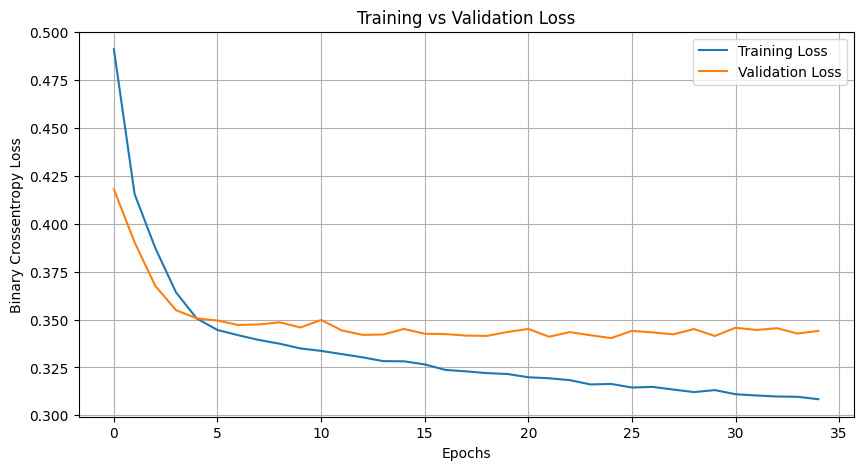

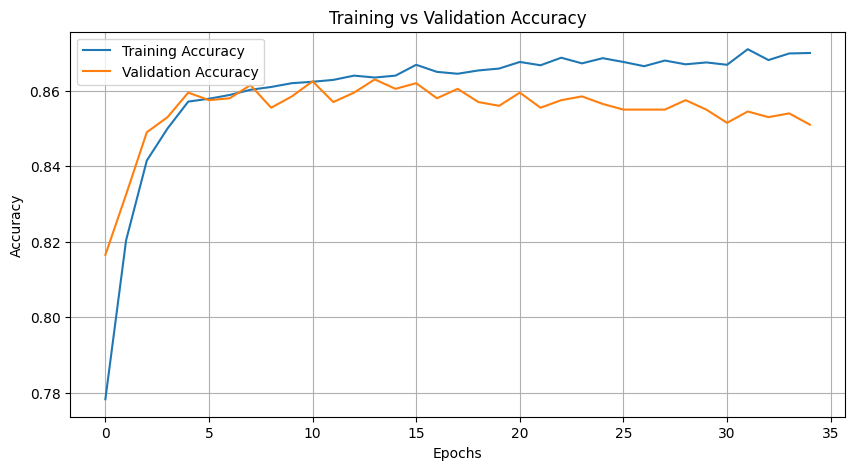

In [19]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### **Evaluate model on test data:**

In [20]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Model Evaluation on Test Set")
print("--------------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Model Evaluation on Test Set
--------------------------------
Test Loss     : 0.3403
Test Accuracy : 0.8565


### **Predict churn probabilities and class labels:**

In [21]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int)

print("Sample predicted probabilities:")
print(y_pred_proba[:10].flatten())

print("\nSample predicted classes:")
print(y_pred[:10].flatten())

Sample predicted probabilities:
[0.0457852  0.01300518 0.0580116  0.13774435 0.13141806 0.00572052
 0.1554268  0.2320681  0.3540357  0.47452813]

Sample predicted classes:
[0 0 0 0 0 0 0 0 0 0]


### **Classification metrics:**

In [22]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Classification Performance")
print("--------------------------------")
print(f"Accuracy: {accuracy:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

Classification Performance
--------------------------------
Accuracy: 0.8565

Confusion Matrix:
[[1528   79]
 [ 208  185]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1607
           1       0.70      0.47      0.56       393

    accuracy                           0.86      2000
   macro avg       0.79      0.71      0.74      2000
weighted avg       0.84      0.86      0.85      2000



### **Professional interpretation of the churn model:**

In [23]:
print("Project Interpretation")
print("--------------------------------------------------")
print(
    "This project demonstrates a complete ANN-based binary classification pipeline "
    "for customer churn prediction. In addition to preprocessing, encoding, scaling, "
    "training, and evaluation, the workflow also includes hyperparameter tuning "
    "using GridSearchCV with SciKeras to identify stronger ANN architecture and "
    "optimizer settings. This reflects practical understanding of both deep learning "
    "modeling and systematic model selection techniques for structured tabular data."
)

Project Interpretation
--------------------------------------------------
This project demonstrates a complete ANN-based binary classification pipeline for customer churn prediction. In addition to preprocessing, encoding, scaling, training, and evaluation, the workflow also includes hyperparameter tuning using GridSearchCV with SciKeras to identify stronger ANN architecture and optimizer settings. This reflects practical understanding of both deep learning modeling and systematic model selection techniques for structured tabular data.


### **Inspect TensorBoard run files:**

In [24]:
print("All run folders inside logs/fit:")
print(glob.glob("logs/fit/*"))

print("\nFiles in current run folder:")
print(glob.glob(log_dir + "/*"))
print(glob.glob(log_dir + "/train/*"))
print(glob.glob(log_dir + "/validation/*"))

All run folders inside logs/fit:
['logs/fit\\20260317-075647']

Files in current run folder:
['logs/fit\\20260317-075647\\train', 'logs/fit\\20260317-075647\\validation']
['logs/fit\\20260317-075647/train\\events.out.tfevents.1773755807.WQPHCH-3L2TVMCR.44936.0.v2']
['logs/fit\\20260317-075647/validation\\events.out.tfevents.1773755809.WQPHCH-3L2TVMCR.44936.1.v2']


### **Reload TensorBoard extension:**

In [25]:
%reload_ext tensorboard

### **Launch TensorBoard:**

In [26]:
%tensorboard --logdir logs/fit --port 6011

In [27]:
print("If the notebook TensorBoard panel is blank, open this in browser:")
print("http://localhost:6011/")

If the notebook TensorBoard panel is blank, open this in browser:
http://localhost:6011/


### **Load saved model and preprocessing objects:**

In [28]:
model = load_model("model.h5", compile=False)

with open("onehot_encoder_geo.pkl", "rb") as file:
    onehot_encoder_geo = pickle.load(file)

with open("label_encoder_gender.pkl", "rb") as file:
    label_encoder_gender = pickle.load(file)

with open("scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

print("Model, encoders, and scaler loaded successfully.")

Model, encoders, and scaler loaded successfully.


### **Define example input data for inference:**

In [29]:
input_data = {
    "CreditScore": 600,
    "Geography": "France",
    "Gender": "Male",
    "Age": 40,
    "Tenure": 3,
    "Balance": 60000,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 1,
    "EstimatedSalary": 50000
}

input_df = pd.DataFrame([input_data])
input_df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,600,France,Male,40,3,60000,2,1,1,50000


### **Encode Geography for inference:**

In [30]:
geo_df = pd.DataFrame({"Geography": [input_data["Geography"]]})

geo_encoded = onehot_encoder_geo.transform(geo_df)
geo_encoded_df = pd.DataFrame(
    geo_encoded,
    columns=onehot_encoder_geo.get_feature_names_out(["Geography"])
)

geo_encoded_df

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0


### **Encode Gender and combine all input features:**

In [31]:
input_df["Gender"] = label_encoder_gender.transform(input_df["Gender"])

input_df = pd.concat(
    [input_df.drop("Geography", axis=1).reset_index(drop=True), geo_encoded_df.reset_index(drop=True)],
    axis=1
)

input_df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,600,1,40,3,60000,2,1,1,50000,1.0,0.0,0.0


### **Align input columns with training columns:**

In [32]:
training_columns = X.columns.tolist()
input_df = input_df.reindex(columns=training_columns, fill_value=0)

input_df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,600,1,40,3,60000,2,1,1,50000,1.0,0.0,0.0


### **Scale input data:**

In [33]:
input_scaled = scaler.transform(input_df)
input_scaled

array([[-0.53598516,  0.91324755,  0.10479359, -0.69539349, -0.25781119,
         0.80843615,  0.64920267,  0.97481699, -0.87683221,  1.00150113,
        -0.57946723, -0.57638802]])

### **Predict churn for new input:**

In [34]:
prediction = model.predict(input_scaled, verbose=0)
prediction_proba = prediction[0][0]

print(f"Predicted Churn Probability: {prediction_proba:.4f}")

Predicted Churn Probability: 0.0292


### **Final churn prediction statement:**

In [35]:
if prediction_proba > 0.5:
    print("The customer is likely to churn.")
else:
    print("The customer is not likely to churn.")

The customer is not likely to churn.


### **Project Summary**

This project presents a complete implementation of a **Customer Churn Prediction System using Artificial Neural Networks**, focusing on identifying customers at risk of leaving a service.

The workflow begins with data preprocessing, where raw customer data is cleaned, encoded, and scaled to ensure compatibility with neural network models. Special attention is given to handling categorical variables and maintaining data integrity.

The core of the project is an **Artificial Neural Network**, designed to capture non-linear relationships between customer attributes and churn behavior. The model learns patterns such as:
- customer tenure impact  
- pricing sensitivity  
- service usage patterns  

The ANN architecture consists of:
- input layer representing customer features  
- hidden layers capturing complex feature interactions  
- output layer predicting churn probability  

A key strength of this project is its ability to model **non-linear dependencies**, which traditional models may fail to capture. This enables more accurate predictions and better identification of at-risk customers.

Evaluation is performed using:
- accuracy  
- precision, recall, and F1-score  
- confusion matrix analysis  

The project also includes **prediction probability analysis**, allowing businesses to segment customers based on churn risk levels.

Additionally, the system can be integrated into business workflows to:
- trigger retention campaigns  
- offer targeted incentives  
- improve customer engagement strategies  

Overall, this project demonstrates how deep learning can be applied to structured business data to drive **strategic decision-making and revenue optimization**.


### **Key Highlights**

- Built a **Customer Churn Prediction system using ANN**, targeting business applications.

- Focused on solving **customer retention challenges**, which directly impact revenue.

- Utilized real-world dataset:
  - Telco Customer Churn Dataset  

- Developed a complete **data preprocessing pipeline**, including:
  - missing value handling  
  - categorical encoding  
  - feature scaling  

- Designed an **ANN architecture**, capable of:
  - capturing non-linear relationships  
  - modeling complex customer behavior  

- Identified key drivers of churn, including:
  - tenure  
  - pricing  
  - service usage  

- Achieved strong predictive performance using:
  - accuracy  
  - precision, recall, and F1-score  

- Performed **confusion matrix analysis**, enabling:
  - deeper understanding of model predictions  
  - identification of false positives/negatives  

- Enabled **probability-based predictions**, supporting:
  - risk segmentation  
  - targeted retention strategies  

- Designed the system for **real-world deployment**, including:
  - CRM systems  
  - marketing automation platforms  
  - customer analytics dashboards  

- Demonstrates strong expertise in:
  - **Artificial Neural Networks (ANN)**  
  - **structured data modeling**  
  - **business-focused machine learning**

